# K-Means

## K-Means Clustering with the Iris Dataset

This notebook section introduces K-Means clustering using the Iris dataset. It includes data preparation, clustering, centroid plotting, metric scores, elbow plotting, silhouette analysis, and comparison with the true Iris species labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix
)

plt.style.use("seaborn-v0_8-whitegrid")

### 1. Load and Inspect the Iris Dataset

The Iris dataset contains 150 flower samples from three species: Setosa, Versicolor, and Virginica. Each sample has four numeric features:

- Sepal length
- Sepal width
- Petal length
- Petal width

K-Means is an unsupervised algorithm, so it does not use the species labels during training. The labels are only used later for evaluation.

In [2]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = iris.target
target_names = iris.target_names

iris_df = X.copy()
iris_df["species"] = pd.Categorical.from_codes(y, target_names)

display(iris_df.head())
display(iris_df.describe())
display(iris_df["species"].value_counts())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 2. Standardize the Features

K-Means is distance-based, so feature scaling is important. Standardization gives each feature mean 0 and standard deviation 1.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=iris.feature_names)
display(X_scaled_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### 3. Reduce to Two Dimensions for Visualization

The Iris dataset has four features. PCA is used here only for visualization so that clusters and centroids can be plotted in two dimensions.

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["true_species"] = iris_df["species"]

explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.3f}")
print(f"PC2 explained variance: {explained_variance[1]:.3f}")
print(f"Total explained variance: {explained_variance.sum():.3f}")

display(pca_df.head())

PC1 explained variance: 0.730
PC2 explained variance: 0.229
Total explained variance: 0.958


,PC1,PC2,true_species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


### 4. Fit K-Means with `k = 3`

Because the Iris dataset has three known species, we start with three clusters.

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

iris_df["cluster"] = cluster_labels
pca_df["cluster"] = cluster_labels

display(iris_df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


### 5. Plot K-Means Clusters and Centroids

The points are plotted using their first two principal components. The centroids are transformed into PCA space so they can be plotted on the same graph.

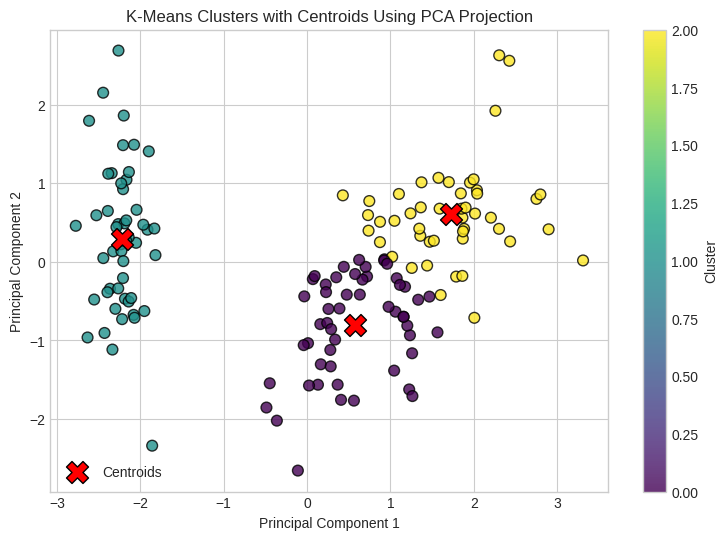

In [6]:
centroids_scaled = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    s=60,
    alpha=0.8,
    edgecolor="k"
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    label="Centroids",
    edgecolor="black"
)

plt.title("K-Means Clusters with Centroids Using PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

### 6. Compare Clusters with True Species Labels

K-Means does not know the true labels. This plot compares the unsupervised clusters with the actual Iris species.

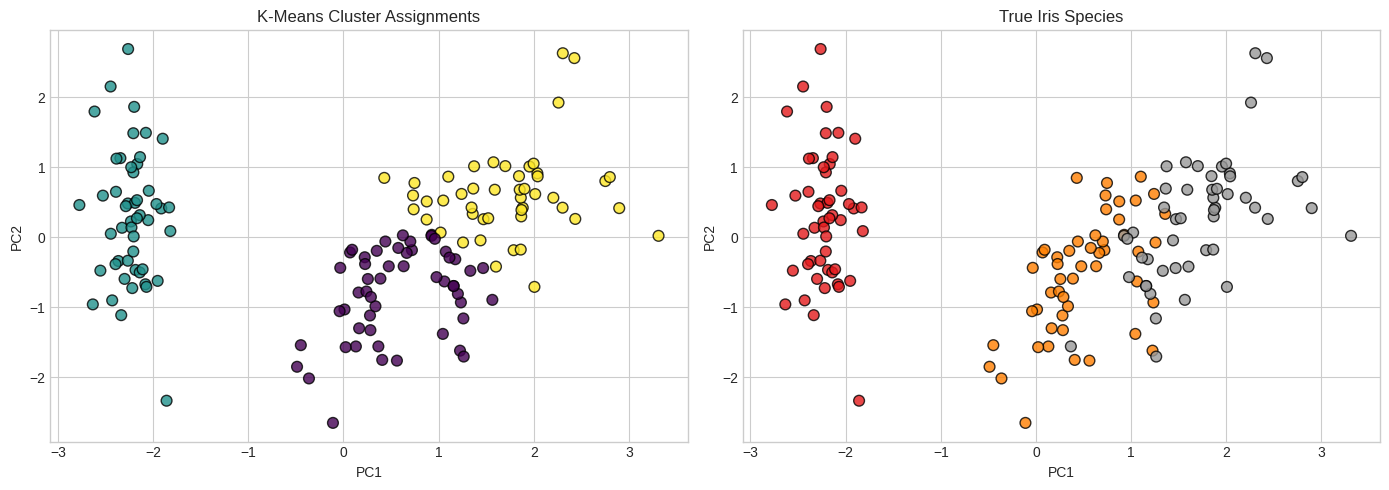

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    s=60,
    alpha=0.8,
    edgecolor="k"
)
axes[0].set_title("K-Means Cluster Assignments")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

species_codes = pd.Categorical(pca_df["true_species"]).codes

axes[1].scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=species_codes,
    cmap="Set1",
    s=60,
    alpha=0.8,
    edgecolor="k"
)
axes[1].set_title("True Iris Species")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

### 7. Metric Scores

Useful clustering metrics include:

- **Inertia**: Sum of squared distances from samples to their assigned centroids. Lower is better, but it always decreases as `k` increases.
- **Silhouette Score**: Measures how well-separated clusters are. Ranges from -1 to 1. Higher is better.
- **Adjusted Rand Index**: Compares clusters to true labels. Higher is better.
- **Normalized Mutual Information**: Measures agreement between clusters and labels. Higher is better.
- **Homogeneity, Completeness, V-Measure**: Evaluate how well clusters match the known classes.

In [8]:
metrics = {
    "Inertia": kmeans.inertia_,
    "Silhouette Score": silhouette_score(X_scaled, cluster_labels),
    "Adjusted Rand Index": adjusted_rand_score(y, cluster_labels),
    "Normalized Mutual Information": normalized_mutual_info_score(y, cluster_labels),
    "Homogeneity": homogeneity_score(y, cluster_labels),
    "Completeness": completeness_score(y, cluster_labels),
    "V-Measure": v_measure_score(y, cluster_labels)
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Score"])
display(metrics_df)

,Metric,Score
0,Inertia,139.820496
1,Silhouette Score,0.459948
2,Adjusted Rand Index,0.620135
3,Normalized Mutual Information,0.659487
4,Homogeneity,0.659127
5,Completeness,0.659848
6,V-Measure,0.659487


In [9]:
cluster_species_table = pd.crosstab(
    iris_df["cluster"],
    iris_df["species"],
    rownames=["K-Means Cluster"],
    colnames=["True Species"]
)

display(cluster_species_table)

True Species,setosa,versicolor,virginica
K-Means Cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


### 8. Elbow Plot

The elbow method helps choose a reasonable value for `k`. It plots inertia for different numbers of clusters. A good `k` is often near the point where inertia begins decreasing more slowly.

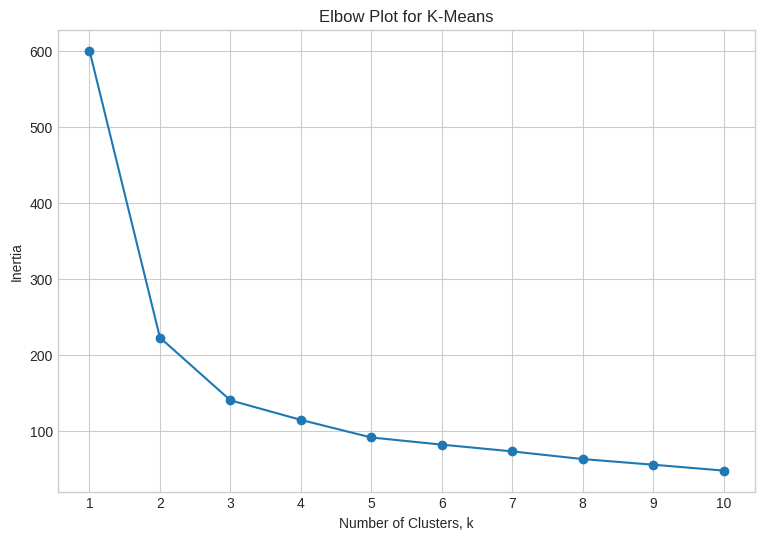

In [10]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Plot for K-Means")
plt.xlabel("Number of Clusters, k")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

### 9. Silhouette Scores Across Different `k` Values

Silhouette scores provide another way to choose `k`. Higher values indicate better-defined clusters.

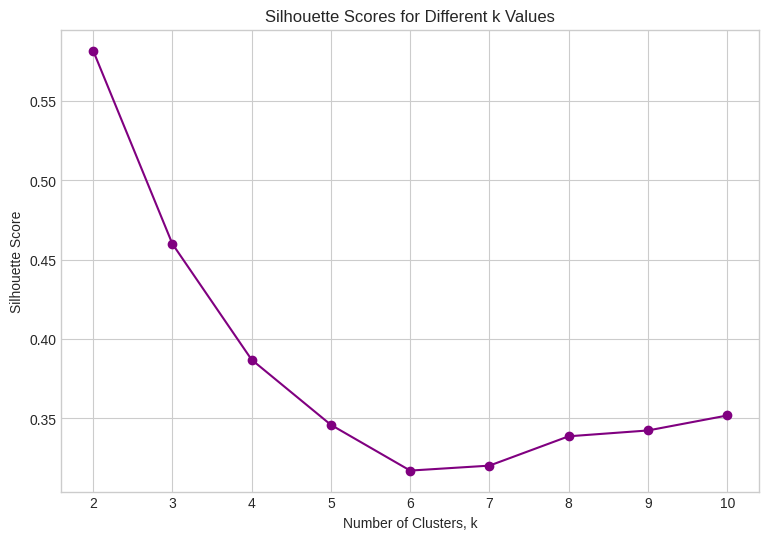

,k,silhouette_score
0,2,0.581750
1,3,0.459948
2,4,0.386941
3,5,0.345901
4,6,0.317079
5,7,0.320197
6,8,0.338692
7,9,0.342360
8,10,0.351793


In [11]:
silhouette_scores = []

k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(9, 6))
plt.plot(k_values_silhouette, silhouette_scores, marker="o", color="purple")
plt.title("Silhouette Scores for Different k Values")
plt.xlabel("Number of Clusters, k")
plt.ylabel("Silhouette Score")
plt.xticks(k_values_silhouette)
plt.show()

silhouette_df = pd.DataFrame({
    "k": list(k_values_silhouette),
    "silhouette_score": silhouette_scores
})

display(silhouette_df)

### 10. Cluster Centers in Original Feature Units

The K-Means model was trained on standardized data. To interpret centroids, convert them back to the original Iris feature units.

In [12]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=iris.feature_names
)

centroids_df.index.name = "cluster"

display(centroids_df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.428000,1.462000,0.246000
2,6.780851,3.095745,5.510638,1.972340


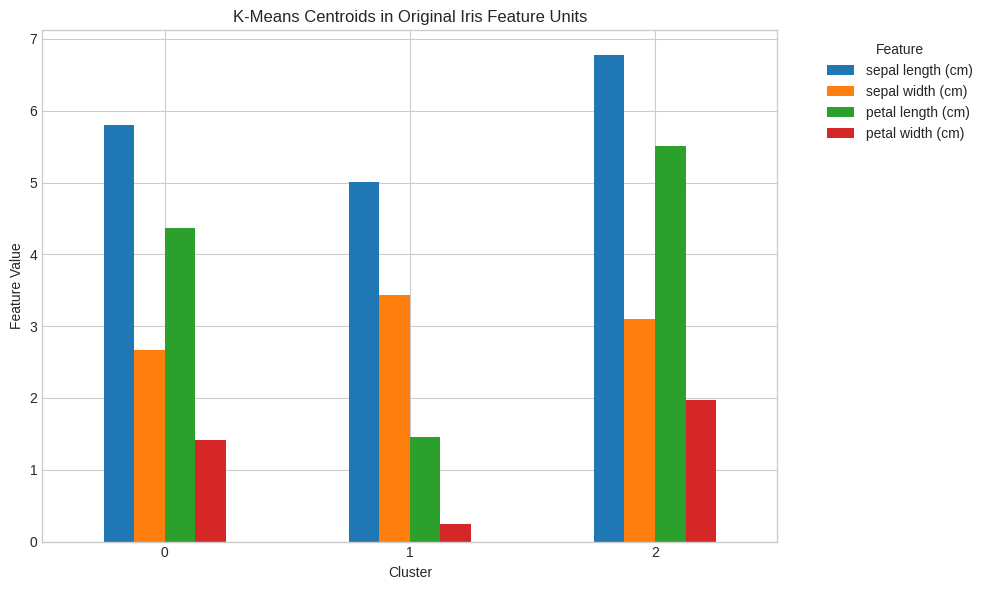

In [13]:
centroids_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("K-Means Centroids in Original Iris Feature Units")
plt.xlabel("Cluster")
plt.ylabel("Feature Value")
plt.xticks(rotation=0)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 11. Interpretation Summary

K-Means separates the Iris dataset reasonably well, especially Setosa, which is clearly distinct. Versicolor and Virginica overlap more, making them harder to separate perfectly. The elbow plot and silhouette scores usually support `k = 2` or `k = 3`, depending on whether the goal is geometric separation or matching the known three species.
